<a href="https://colab.research.google.com/github/KhadeejathRushda/Rushda/blob/master/lung_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# --- ALL IMPORTS ---
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.utils import class_weight
from tensorflow.keras.models import load_model
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- LIME IMPORTS ---
try:
    import lime
except ImportError:
    !pip install lime
    import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

print("All libraries imported successfully!")
import os
import zipfile

# Create a temporary folder to hold all images
os.makedirs('/content/full_dataset', exist_ok=True)

# Unzip the first file (the 4 classes)
with zipfile.ZipFile('//content/drive/MyDrive/MyProject/archive(1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/full_dataset')

# Unzip the second file (the Nodule class)
with zipfile.ZipFile('/content/drive/MyDrive/MyProject/Nodule.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/full_dataset')
import os
print(os.listdir('/content/full_dataset'))
!pip install split-folders
import splitfolders

# This creates a folder called 'nodule_output' with train, val, and test inside
splitfolders.ratio('/content/full_dataset/Nodule',
                   output='/content/nodule_output',
                   seed=1337, ratio=(.8, .1, .1))

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d0a34394d60f20333cbdc844321bc1994372da0757fe6de274ff5cfe3668722f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
All libraries imported successfully!
['Nodule', 'data']


Copying files: 6331 files [00:01, 4252.77 files/s]


In [ ]:
import shutil
# Define where the pieces need to go
base_path = '/content/full_dataset/data'

# Move Train
shutil.move('/content/nodule_output/train', os.path.join(base_path, 'train/Nodule'))

# Move Val
shutil.move('/content/nodule_output/val', os.path.join(base_path, 'val/Nodule'))

# Move Test
shutil.move('/content/nodule_output/test', os.path.join(base_path, 'test/Nodule'))

print("Nodule class is now merged into your train/test/val folders!")
print("Classes in Train:", os.listdir('/content/full_dataset/data/train'))


Nodule class is now merged into your train/test/val folders!
Classes in Train: ['Nodule', 'UNKNOWN', 'NORMAL', 'PNEUMONIA', 'TUBERCULOSIS']


In [ ]:
import cv2
import numpy as np
import tensorflow as tf

IMG_SIZE = (300, 300)
BATCH_SIZE = 16

def apply_clahe(image):
    # image coming in is (300, 300, 3)
    img = image.numpy().astype(np.uint8)

    if len(img.shape) == 3 and img.shape[2] == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    elif len(img.shape) == 3 and img.shape[2] == 1:
        gray = img[:, :, 0]
    else:
        gray = img

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    final_img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    # Return as float32
    return final_img.astype(np.float32)

def preprocess_dataset(image, label):
    # This handles the 3D -> 3D transformation
    image = tf.py_function(apply_clahe, [image], tf.float32)
    image.set_shape((300, 300, 3))
    image = tf.keras.applications.efficientnet_v2.preprocess_input(image)
    return image, label

# Load Datasets UNBATCHED first, then map, then batch
def load_and_fix_ds(path, shuffle=True):
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        image_size=IMG_SIZE,
        label_mode='categorical',
        color_mode='rgb',
        batch_size=None, # Load as individual samples
        shuffle=shuffle
    )
    # Apply CLAHE to individual images
    ds = ds.map(preprocess_dataset, num_parallel_calls=tf.data.AUTOTUNE)
    # NOW Batch them into 4D tensors
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = load_and_fix_ds('/content/full_dataset/data/train')
val_ds = load_and_fix_ds('/content/full_dataset/data/val')
test_ds = load_and_fix_ds('/content/full_dataset/data/test', shuffle=False)

Found 18092 files belonging to 5 classes.
Found 1394 files belonging to 5 classes.
Found 2161 files belonging to 5 classes.


In [ ]:
import os
import numpy as np
from sklearn.utils import class_weight

# 1. Define the training directory
train_dir = '/content/full_dataset/data/train'

# 2. Get the list of classes and all labels
classes = sorted(os.listdir(train_dir))
y_train = []

print("Counting files for balanced weights...")
for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    num_files = len(os.listdir(class_path))
    y_train.extend([i] * num_files)
    print(f" - {class_name}: {num_files} images")

y_train = np.array(y_train)

# 3. Calculate 'Balanced' weights
# Formula: total_samples / (n_classes * class_samples)
unique_classes = np.unique(y_train)
computed_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)

# 4. Create the dictionary
class_weights = dict(zip(unique_classes, computed_weights))

# 5. Medical Safety Adjustment
# We boost the Nodule weight (index 1) by an extra 20% to prioritize recall
if 'Nodule' in classes:
    nodule_idx = classes.index('Nodule')
    class_weights[nodule_idx] = class_weights[nodule_idx] * 1.2

print("\n--- Final Balanced Weights ---")
for i, weight in class_weights.items():
    print(f"Class {i} ({classes[i]}): {weight:.4f}")

Counting files for balanced weights...
 - NORMAL: 4667 images
 - Nodule: 5064 images
 - PNEUMONIA: 3633 images
 - TUBERCULOSIS: 3573 images
 - UNKNOWN: 1155 images

--- Final Balanced Weights ---
Class 0 (NORMAL): 0.7753
Class 1 (Nodule): 0.8574
Class 2 (PNEUMONIA): 0.9960
Class 3 (TUBERCULOSIS): 1.0127
Class 4 (UNKNOWN): 3.1328


In [ ]:
from tensorflow.keras import layers, models, optimizers

def build_final_model(num_classes=5):
    inputs = layers.Input(shape=(300, 300, 3))

    # 1. Base Model (EfficientNetV2-B3)
    base_model = tf.keras.applications.EfficientNetV2B3(
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )

    # Fine-Tuning: We start with the base model trainable
    base_model.trainable = True

    x = base_model(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x) # Higher dropout to handle "unseen" variety

    # 4. Final Output with Label Smoothing
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    # Surgical Learning Rate: Very low to keep the pre-trained weights stable
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy', tf.keras.metrics.Recall(name='nodule_recall')]
    )
    return model

model = build_final_model()
model.summary()

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 1536)           │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         7,685 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,944,451 (49.38 MB)

 Trainable params: 12,832,163 (48.95 MB)

 Non-trainable params: 112,288 (438.62 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Ensure your Drive path is correct
checkpoint_path = '/content/drive/MyDrive/MyProject/Lung_V5_Final.keras'

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

print("Starting Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # EarlyStopping will likely trigger around 12-15
    class_weight=class_weights,
    callbacks=callbacks
)

Starting Training...
Epoch 1/20
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.5667 - loss: 1.4788 - nodule_recall: 0.4977
Epoch 1: val_accuracy improved from None to 0.97198, saving model to /content/drive/MyDrive/MyProject/Lung_V5_Final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MyProject/Lung_V5_Final.keras
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 571s 374ms/step - accuracy: 0.7292 - loss: 1.0714 - nodule_recall: 0.6814 - val_accuracy: 0.9720 - val_loss: 0.6133 - val_nodule_recall: 0.9698
Epoch 2/20
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.8827 - loss: 0.7667 - nodule_recall: 0.8594
Epoch 2: val_accuracy improved from 0.97198 to 0.98348, saving model to /content/drive/MyDrive/MyProject/Lung_V5_Final.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MyProject/Lung_V5_Final.keras
1130/1130 ━━━━━━━━━━━━━━━━━━━━ 420s 371ms/step - accuracy: 0.8912 - loss: 0.7423 - nodule_recall: 0.8686 - val_accuracy: 0.9835 - val_loss: 0.5969 - val_

In [ ]:
# 1. Load the best saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/MyProject/Lung_V5_Final.keras')

# 2. Evaluate on the Test Set
results = model.evaluate(test_ds)
print(f"Test Accuracy: {results[1]*100:.2f}%")
print(f"Test Nodule Recall: {results[2]*100:.2f}%")

# 3. Generate Predictions for Confusion Matrix
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

from sklearn.metrics import classification_report
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

135/135 ━━━━━━━━━━━━━━━━━━━━ 47s 192ms/step - accuracy: 0.9884 - loss: 0.4907 - nodule_recall: 0.9884
Test Accuracy: 98.84%
Test Nodule Recall: 98.84%

--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      NORMAL       0.97      0.99      0.98       548
      Nodule       1.00      1.00      1.00       634
   PNEUMONIA       0.99      0.98      0.98       427
TUBERCULOSIS       1.00      0.98      0.99       417
     UNKNOWN       1.00      1.00      1.00       134

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



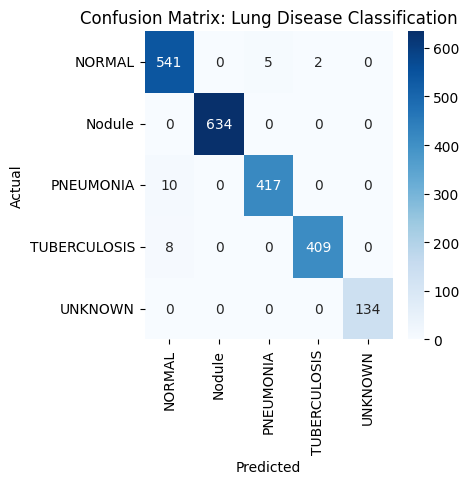

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate Predictions
y_pred = []
y_true = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# 2. Plot Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Lung Disease Classification')
plt.show()

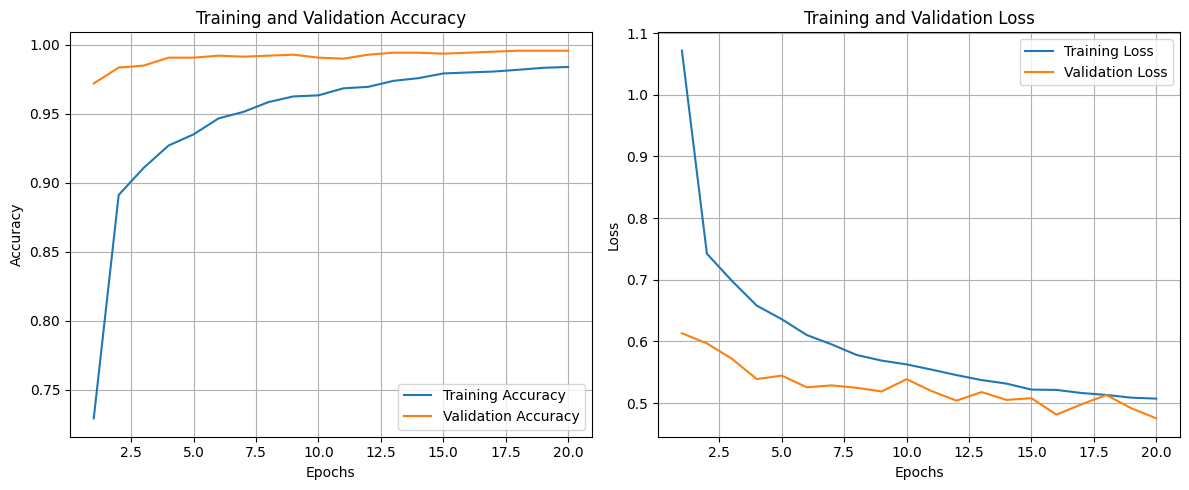

In [ ]:
import matplotlib.pyplot as plt

# Plotting Accuracy and Loss Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

Saving diagram-export-4-6-2026-2_23_41-PM.png to diagram-export-4-6-2026-2_23_41-PM.png


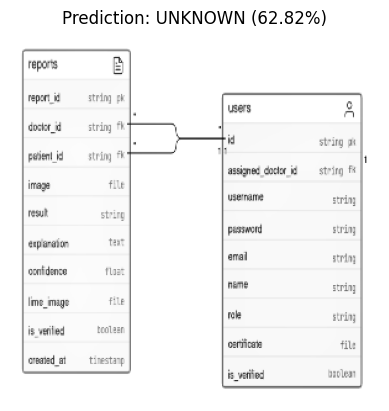

File: diagram-export-4-6-2026-2_23_41-PM.png | Result: UNKNOWN | Confidence: 0.6282


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files

# 1. Load the model (Run once)
model_path = '/content/drive/MyDrive/MyProject/Lung_V5_Final.keras'
model = tf.keras.models.load_model(model_path)
class_names = ['NORMAL', 'Nodule', 'PNEUMONIA', 'TUBERCULOSIS', 'UNKNOWN']

def predict_lung_disease(img_path):
    # --- PREPROCESSING (Matches Training Exactly) ---
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply CLAHE
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    # Back to RGB and Resize to 300x300
    img_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    img_resized = cv2.resize(img_rgb, (300, 300))

    # Expand dims (1, 300, 300, 3) and apply EfficientNet Scaling
    img_array = np.expand_dims(img_resized, axis=0).astype(np.float32)
    img_preprocessed = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

    # --- INFERENCE ---
    predictions = model.predict(img_preprocessed, verbose=0)
    score = predictions[0]
    class_idx = np.argmax(score)

    return class_names[class_idx], score[class_idx], img_resized

# --- EXECUTE TEST ---
uploaded = files.upload()
for fn in uploaded.keys():
    label, confidence, processed_img = predict_lung_disease(fn)

    plt.imshow(processed_img.astype(np.uint8))
    plt.title(f"Prediction: {label} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"File: {fn} | Result: {label} | Confidence: {confidence:.4f}")

Saving n4.jpg to n4 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


  0%|          | 0/500 [00:00<?, ?it/s]

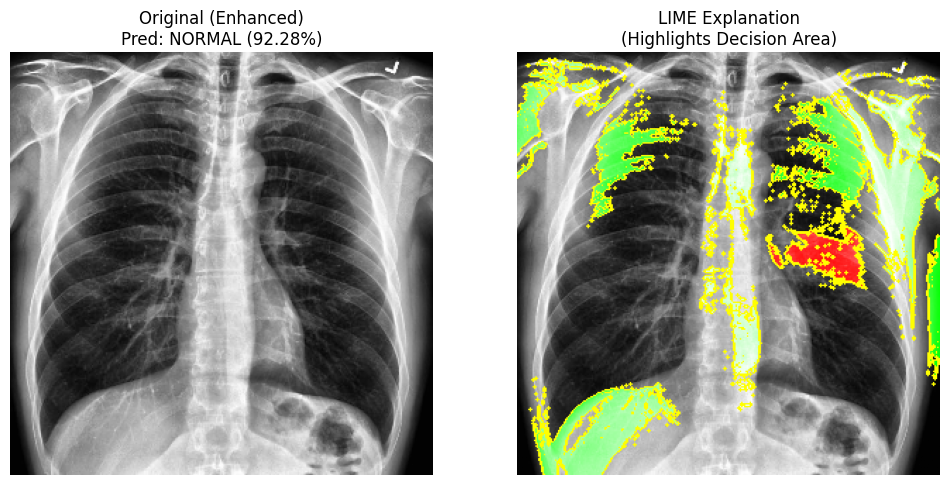

In [ ]:
from google.colab import files
from lime import lime_image
from skimage.segmentation import mark_boundaries
import io

# 1. Setup Explainer
explainer = lime_image.LimeImageExplainer()

# 2. Upload Function
uploaded = files.upload()

for filename in uploaded.keys():
    # --- PREPROCESS ---
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Same CLAHE logic as training
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    img_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    img_resized = cv2.resize(img_rgb, (300, 300))

    # --- PREDICT ---
    img_batch = np.expand_dims(img_resized, axis=0).astype(np.float32)
    img_preprocessed = tf.keras.applications.efficientnet_v2.preprocess_input(img_batch)
    preds = model.predict(img_preprocessed)
    class_idx = np.argmax(preds[0])
    conf = preds[0][class_idx]

    # --- LIME EXPLANATION ---
    def predict_fn(images):
        return model.predict(tf.keras.applications.efficientnet_v2.preprocess_input(images), verbose=0)

    explanation = explainer.explain_instance(
        img_resized.astype('double'),
        predict_fn,
        top_labels=1,
        num_samples=500 # Use 1000 for better quality if GPU is fast
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=False, num_features=10, hide_rest=False
    )

    # --- DISPLAY ---
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    plt.title(f"Original (Enhanced)\nPred: {class_names[class_idx]} ({conf*100:.2f}%)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title(f"LIME Explanation\n(Highlights Decision Area)")
    plt.axis('off')

    plt.show()

In [ ]:
from google.colab import files

# 1. Final save to the local Colab environment
model_name = 'Lung_V5_Final.keras'
model.save(model_name)

# 2. Trigger the download to your PC
files.download(model_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

# Try loading it back
test_load = tf.keras.models.load_model('Lung_V5_Final.keras')

# If this prints 5, the model structure is perfectly preserved
print("Model Output Classes:", test_load.output_shape[-1])

Model Output Classes: 5


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
# Run this in a Colab cell
!pip install tensorflow==2.19.0
import tensorflow as tf
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
model_path = '/content/drive/MyDrive/MyProject/Lung_V5_Final.keras'
model = tf.keras.models.load_model(model_path)
# 1. Final save to the local Colab environment
model_name = 'Lung_V5_Final.keras'
model.save(model_name)

# 2. Trigger the download to your PC
files.download(model_name)

Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>